In [1]:
import rasterio
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import os

Month 3: Extreme high rainfall detected. Using dynamic positive scale.


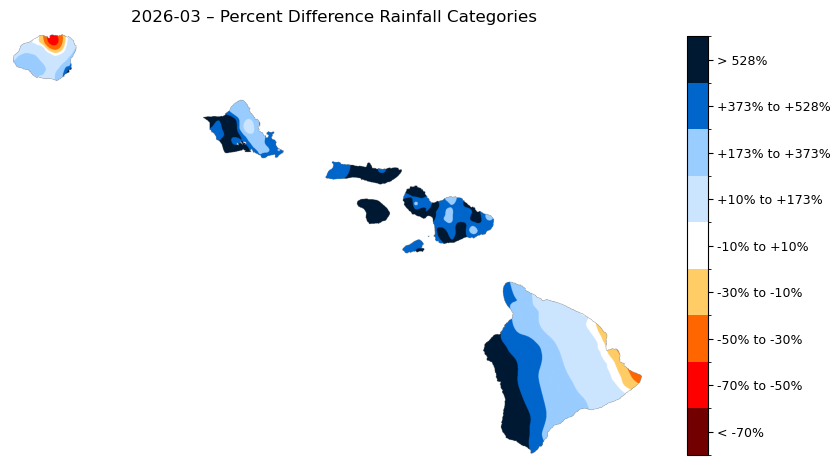

Successfully saved categorized raster to ../public/tifs/rainfall_pdiff_cat.tif
Dataset leans wet. Legend ordered Wet to Dry.
Successfully saved legend JSON to ../public/tifs/rainfall_legend.json


In [ ]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import json

year = '2026'
month = 3

dataset = 'rainfall'
local_dep_dir = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/scripts/data/dependencies"

  # 1. Load the Climatology Raster
climo_file = os.path.join(local_dep_dir, f"climo/{dataset}/{dataset}_1991-2020_{month:02d}.tif")
with rasterio.open(climo_file) as src:
    rf_climo = src.read(1)
    nodata_climo = src.nodata

masked_climo = np.ma.masked_equal(rf_climo, nodata_climo)

# 2. Load the Current Rainfall Raster
raster_dir = os.path.join(local_dep_dir, dataset, f"{dataset}_{year}_{month:02d}.tif")
with rasterio.open(raster_dir) as src:
    rf = src.read(1)
    nodata_rf = src.nodata
    profile = src.profile

masked_rf = np.ma.masked_equal(rf, nodata_rf)

# 3. Calculate Percent Difference (In Memory)
pdiff = (masked_rf - masked_climo) / masked_climo * 100
combined_mask = np.ma.getmask(masked_rf) | np.ma.getmask(masked_climo)
pdiff_masked = np.ma.array(pdiff, mask=combined_mask)

data = pdiff_masked.data
is_data_mask = ~pdiff_masked.mask

valid_data = data[is_data_mask]
if len(valid_data) == 0:
    raise ValueError("No valid data found in the raster!")

# Define our anchor for "Normal" rainfall
neutral_low = -10.0
neutral_high = 10.0

# Isolate the strictly positive pixels for dynamic calculation
pos_data = valid_data[valid_data > neutral_high]

n_breaks = [-70, -50, -30]
default_p_breaks = [30, 50, 7]

# Define what constitutes a "crazy" high rainfall event (e.g., 98th percentile > +150%)
extreme_high_threshold = 150
is_crazy_high = np.percentile(valid_data, 98) > extreme_high_threshold

if is_crazy_high:
    print(f"Month {month}: Extreme high rainfall detected. Using dynamic positive scale.")
    if len(pos_data) > 0:
        p_breaks = np.percentile(pos_data, [25, 50, 75])
    else:
        p_breaks = default_p_breaks
else:
    print(f"Month {month}: Standard rainfall variation. Using default static scale.")
    p_breaks = default_p_breaks

base_colors = [
    "#730000", "#FF0000", "#FF6600", "#FFCC66", # Negatives (0-3)
    "#FFFFFF",                                 # Neutral (4)
    "#CCE5FF", "#99CCFF", "#0066CC", "#001933" # Positives (5-8)
]

# Construct the mathematical bounds using the breaks
bounds = [
    (-np.inf, n_breaks[0]),       # 0: < Dark Red
    (n_breaks[0], n_breaks[1]),   # 1: Red
    (n_breaks[1], n_breaks[2]),   # 2: Orange
    (n_breaks[2], neutral_low),   # 3: Light Orange
    (neutral_low, neutral_high),  # 4: White
    (neutral_high, p_breaks[0]),  # 5: Very Light Blue
    (p_breaks[0], p_breaks[1]),   # 6: Light Blue
    (p_breaks[1], p_breaks[2]),   # 7: Blue
    (p_breaks[2], np.inf)         # 8: > Dark Blue
]

sync_config = []
for i, (low, high) in enumerate(bounds):
    color = base_colors[i]
    
    if i == 0:
        label = f"< {high:.0f}%"
    elif i == 8:
        label = f"> {low:.0f}%"
    else:
        low_str = f"+{low:.0f}" if low > 0 else f"{low:.0f}"
        high_str = f"+{high:.0f}" if high > 0 else f"{high:.0f}"
        label = f"{low_str}% to {high_str}%"
        
    sync_config.append((low, high, color, label))

colors = [c for _, _, c, _ in sync_config]
labels = [l for _, _, _, l in sync_config]

categorical = np.full(data.shape, 255, dtype=np.uint8)

for i, (low, high) in enumerate(bounds):
    if i == 8:
        mask = is_data_mask & (data >= low)
    else:
        mask = is_data_mask & (data >= low) & (data < high)
        
    categorical[mask] = i

cmap = ListedColormap(colors)
cmap.set_bad(color='#00000000') 

norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)

output_path = "../public/tifs/rainfall_pdiff_cat.tif"
with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(categorical, 1)

print(f"Successfully saved categorized raster to {output_path}")

is_wet_heavy = np.median(valid_data) > 0

legend_items = []
for i, (low, high, color, label) in enumerate(sync_config):
    # JSON doesn't handle np.inf well, so we convert infinities to None (null in JSON)
    # and standard numpy floats to standard Python floats.
    safe_low = None if np.isinf(low) else float(low)
    safe_high = None if np.isinf(high) else float(high)
    
    legend_items.append({
        "category_value": i, # Matches the pixel value in your TIF
        "color": color,
        "label": label,
        "min": safe_low,
        "max": safe_high
    })

# The base sync_config is ordered Dry to Wet (Index 0 is < -75%, Index 8 is > +75%).
# If it's wet heavy, reverse the list so Wet (Blues) shows at the top of the Angular legend.
if is_wet_heavy:
    legend_items.reverse()
    print("Dataset leans wet. Legend ordered Wet to Dry.")
else:
    print("Dataset leans dry. Legend ordered Dry to Wet.")

# Package it up with some helpful metadata for the frontend
legend_data = {
    "dataset": dataset,
    "year": year,
    "month": month,
    "is_wet_heavy": bool(is_wet_heavy),
    "items": legend_items
}

# Save the JSON alongside the TIF
json_output_path = "../public/tifs/rainfall_legend.json"
with open(json_output_path, 'w') as f:
    json.dump(legend_data, f, indent=4)

print(f"Successfully saved legend JSON to {json_output_path}")

Month 1: Standard rainfall variation. Using default static scale.


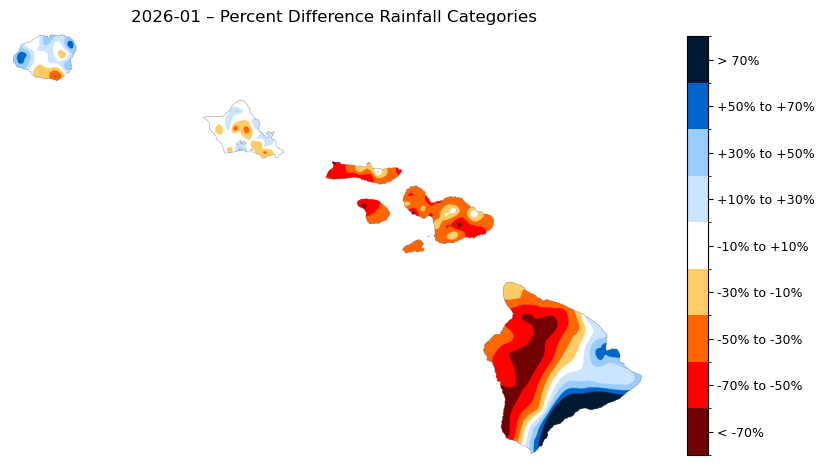

Dataset leans dry. Legend ordered Dry to Wet.
Month 2: Extreme high rainfall detected. Using dynamic positive scale.


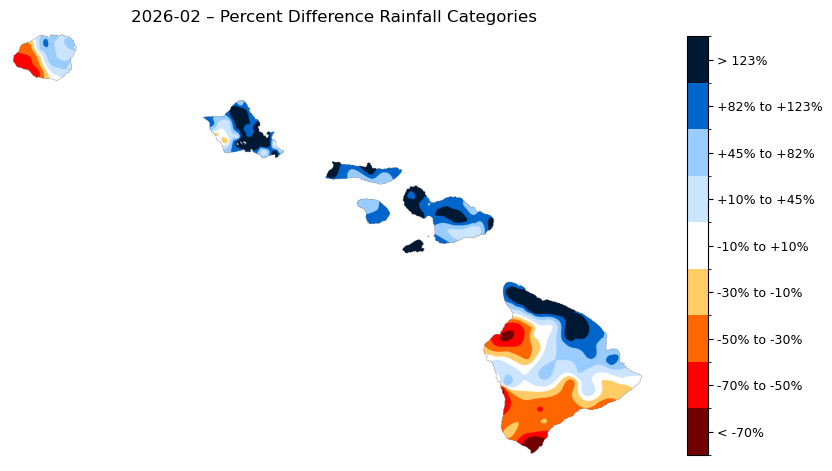

Dataset leans wet. Legend ordered Wet to Dry.
Month 3: Extreme high rainfall detected. Using dynamic positive scale.


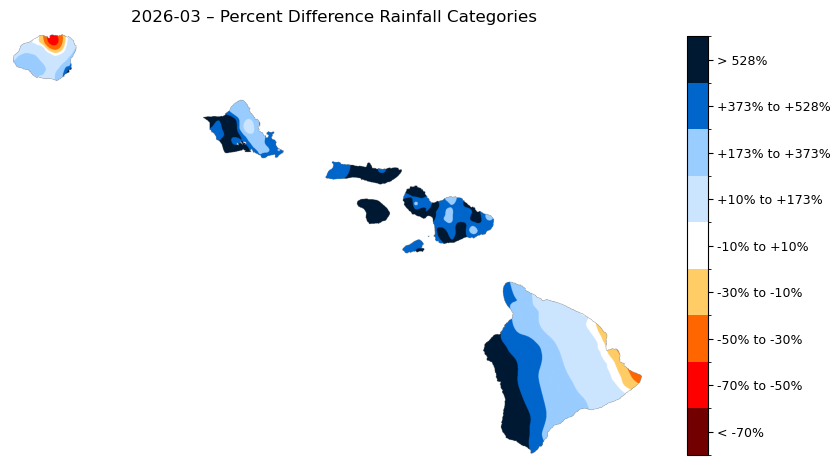

Dataset leans wet. Legend ordered Wet to Dry.


In [49]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

year = '2026'
dataset = 'rainfall'
local_dep_dir = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/scripts/data/dependencies"

for month in range(1, 3+1):
  dataset = 'rainfall'
  local_dep_dir = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/scripts/data/dependencies"

    # 1. Load the Climatology Raster
  climo_file = os.path.join(local_dep_dir, f"climo/{dataset}/{dataset}_1991-2020_{month:02d}.tif")
  with rasterio.open(climo_file) as src:
      rf_climo = src.read(1)
      nodata_climo = src.nodata

  masked_climo = np.ma.masked_equal(rf_climo, nodata_climo)

  # 2. Load the Current Rainfall Raster
  raster_dir = os.path.join(local_dep_dir, dataset, f"{dataset}_{year}_{month:02d}.tif")
  with rasterio.open(raster_dir) as src:
      rf = src.read(1)
      nodata_rf = src.nodata

  masked_rf = np.ma.masked_equal(rf, nodata_rf)

  # 3. Calculate Percent Difference (In Memory)
  pdiff = (masked_rf - masked_climo) / masked_climo * 100
  combined_mask = np.ma.getmask(masked_rf) | np.ma.getmask(masked_climo)
  pdiff_masked = np.ma.array(pdiff, mask=combined_mask)

  data = pdiff_masked.data
  is_data_mask = ~pdiff_masked.mask

  valid_data = data[is_data_mask]
  if len(valid_data) == 0:
      raise ValueError("No valid data found in the raster!")

  # Define our anchor for "Normal" rainfall
  neutral_low = -10.0
  neutral_high = 10.0

  # Isolate the strictly positive pixels for dynamic calculation
  pos_data = valid_data[valid_data > neutral_high]

  # --- DEFAULT VS DYNAMIC SCALE LOGIC ---

  # Negative values are capped at -100%, so we can confidently use static breaks
  n_breaks = [-70, -50, -30]

  # Sensible default breaks for normal positive anomalies
  default_p_breaks = [30, 50, 70]

  # Define what constitutes a "crazy" high rainfall event (e.g., 98th percentile > +150%)
  extreme_high_threshold = 150
  is_crazy_high = np.percentile(valid_data, 98) > extreme_high_threshold

  if is_crazy_high:
      print(f"Month {month}: Extreme high rainfall detected. Using dynamic positive scale.")
      if len(pos_data) > 0:
          p_breaks = np.percentile(pos_data, [25, 50, 75])
      else:
          p_breaks = default_p_breaks
  else:
      print(f"Month {month}: Standard rainfall variation. Using default static scale.")
      p_breaks = default_p_breaks

  # --------------------------------------

  base_colors = [
      "#730000", "#FF0000", "#FF6600", "#FFCC66", # Negatives (0-3)
      "#FFFFFF",                                 # Neutral (4)
      "#CCE5FF", "#99CCFF", "#0066CC", "#001933" # Positives (5-8)
  ]

  # Construct the mathematical bounds using the breaks
  bounds = [
      (-np.inf, n_breaks[0]),       # 0: < Dark Red
      (n_breaks[0], n_breaks[1]),   # 1: Red
      (n_breaks[1], n_breaks[2]),   # 2: Orange
      (n_breaks[2], neutral_low),   # 3: Light Orange
      (neutral_low, neutral_high),  # 4: White
      (neutral_high, p_breaks[0]),  # 5: Very Light Blue
      (p_breaks[0], p_breaks[1]),   # 6: Light Blue
      (p_breaks[1], p_breaks[2]),   # 7: Blue
      (p_breaks[2], np.inf)         # 8: > Dark Blue
  ]

  sync_config = []
  for i, (low, high) in enumerate(bounds):
      color = base_colors[i]
      
      if i == 0:
          label = f"< {high:.0f}%"
      elif i == 8:
          label = f"> {low:.0f}%"
      else:
          low_str = f"+{low:.0f}" if low > 0 else f"{low:.0f}"
          high_str = f"+{high:.0f}" if high > 0 else f"{high:.0f}"
          label = f"{low_str}% to {high_str}%"
          
      sync_config.append((low, high, color, label))

  colors = [c for _, _, c, _ in sync_config]
  labels = [l for _, _, _, l in sync_config]

  categorical = np.full(data.shape, 255, dtype=np.uint8)

  for i, (low, high) in enumerate(bounds):
      if i == 8:
          mask = is_data_mask & (data >= low)
      else:
          mask = is_data_mask & (data >= low) & (data < high)
          
      categorical[mask] = i

  cmap = ListedColormap(colors)
  cmap.set_bad(color='#00000000') 

  norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

  plt.figure(figsize=(9, 6))

  categorical_masked = np.ma.masked_where(categorical == 255, categorical)

  im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
  plt.axis("off")

  cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
  cbar.set_ticks(range(len(colors)))
  cbar.set_ticklabels(labels)
  cbar.ax.tick_params(labelsize=9)
  plt.title(f"{year}-{month:02d} – Percent Difference Rainfall Categories")

  plt.show()

  profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)


  is_wet_heavy = np.median(valid_data) > 0

  legend_items = []
  for i, (low, high, color, label) in enumerate(sync_config):
      # JSON doesn't handle np.inf well, so we convert infinities to None (null in JSON)
      # and standard numpy floats to standard Python floats.
      safe_low = None if np.isinf(low) else float(low)
      safe_high = None if np.isinf(high) else float(high)
      
      legend_items.append({
          "category_value": i, # Matches the pixel value in your TIF
          "color": color,
          "label": label,
          "min": safe_low,
          "max": safe_high
      })

  if is_wet_heavy:
      legend_items.reverse()
      print("Dataset leans wet. Legend ordered Wet to Dry.")
  else:
      print("Dataset leans dry. Legend ordered Dry to Wet.")


Month 1: Extreme high rainfall detected. Using dynamic positive scale.


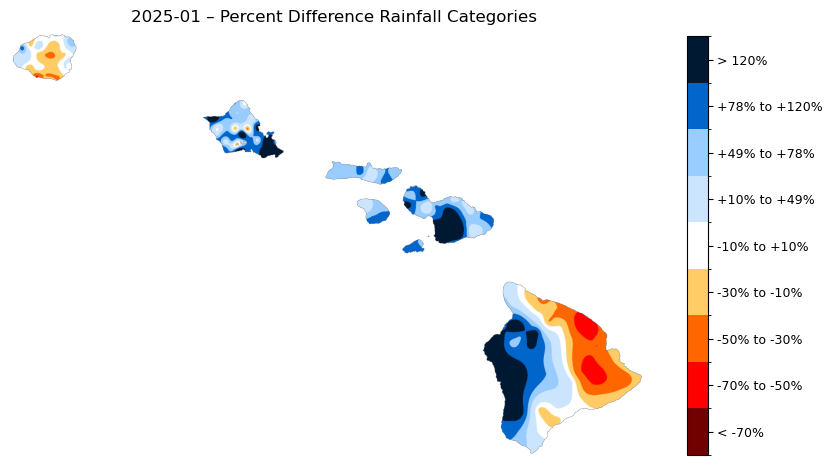

Dataset leans wet. Legend ordered Wet to Dry.
Month 2: Standard rainfall variation. Using default static scale.


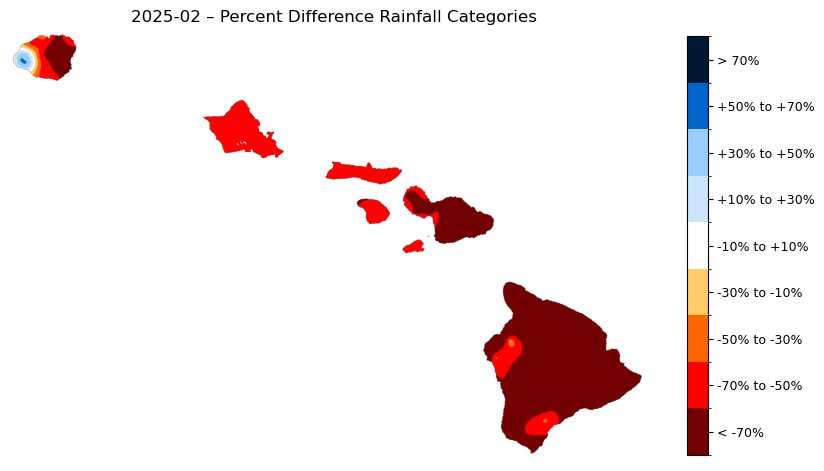

Dataset leans dry. Legend ordered Dry to Wet.
Month 3: Standard rainfall variation. Using default static scale.


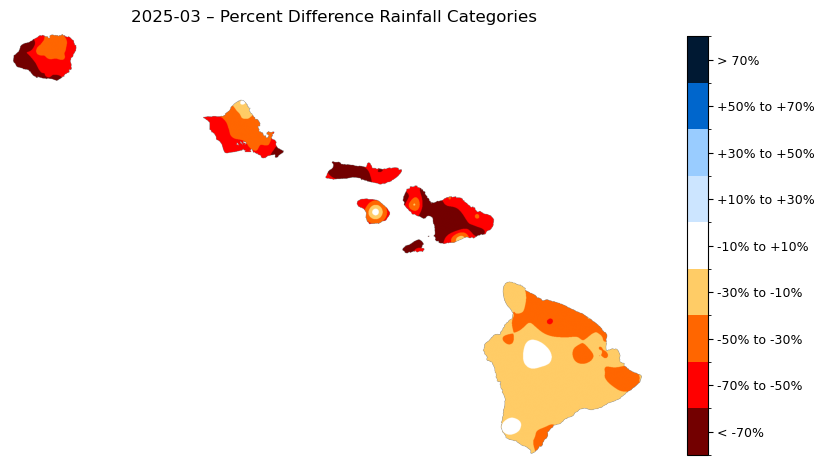

Dataset leans dry. Legend ordered Dry to Wet.
Month 4: Extreme high rainfall detected. Using dynamic positive scale.


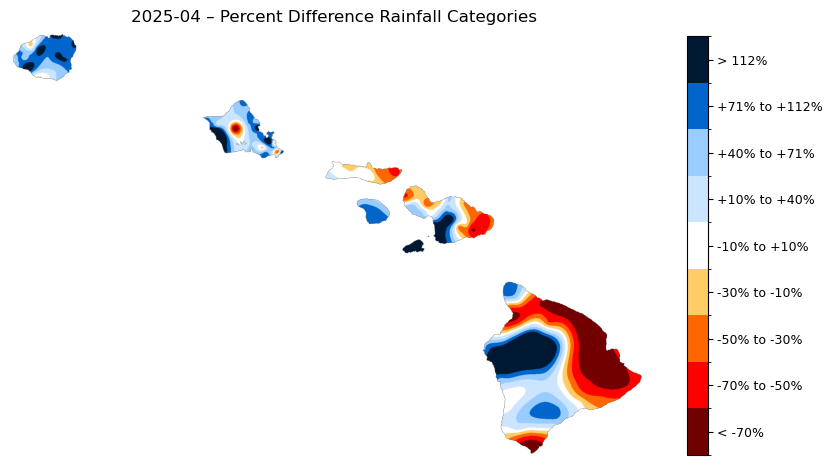

Dataset leans wet. Legend ordered Wet to Dry.
Month 5: Standard rainfall variation. Using default static scale.


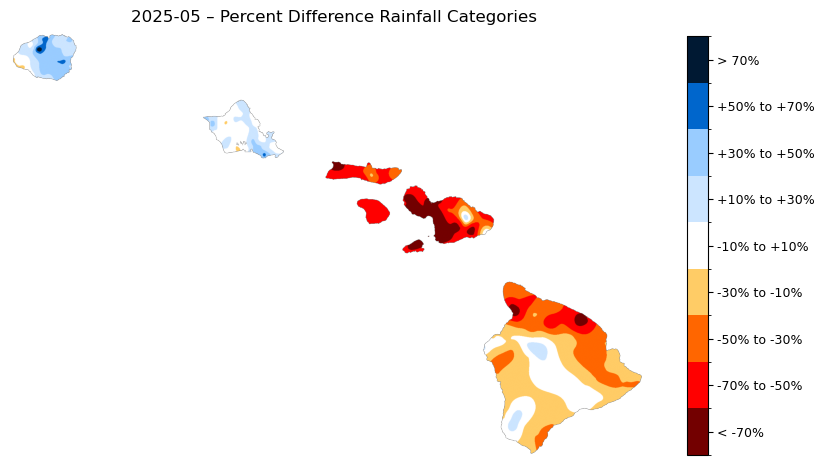

Dataset leans dry. Legend ordered Dry to Wet.
Month 6: Standard rainfall variation. Using default static scale.


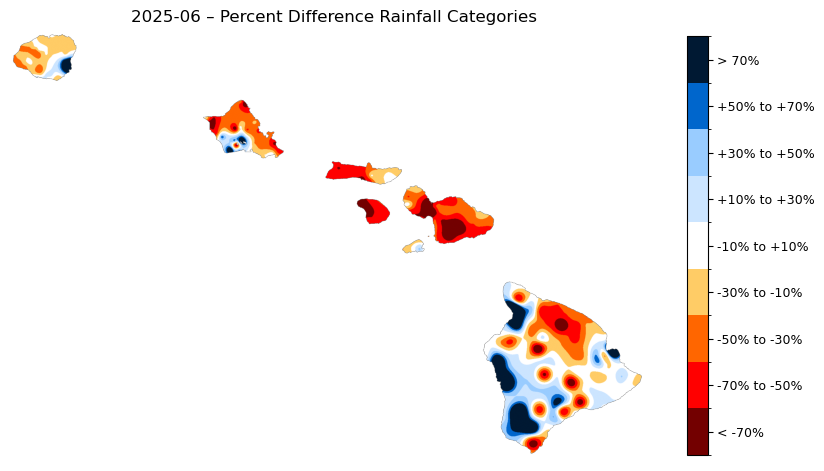

Dataset leans dry. Legend ordered Dry to Wet.
Month 7: Standard rainfall variation. Using default static scale.


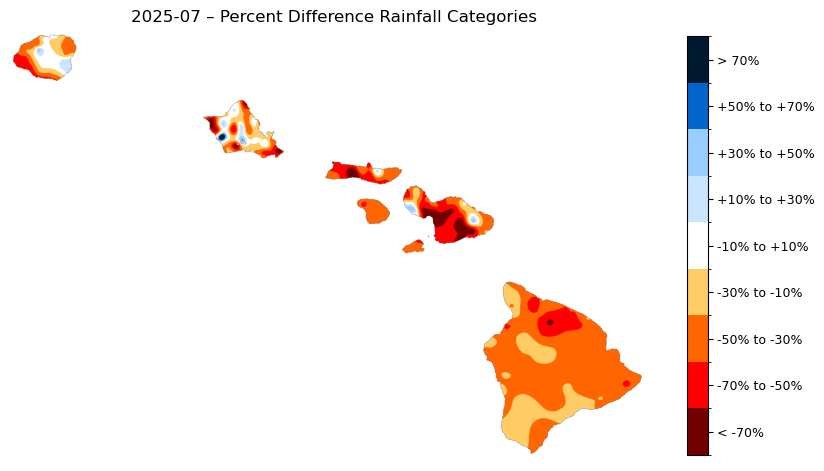

Dataset leans dry. Legend ordered Dry to Wet.
Month 8: Standard rainfall variation. Using default static scale.


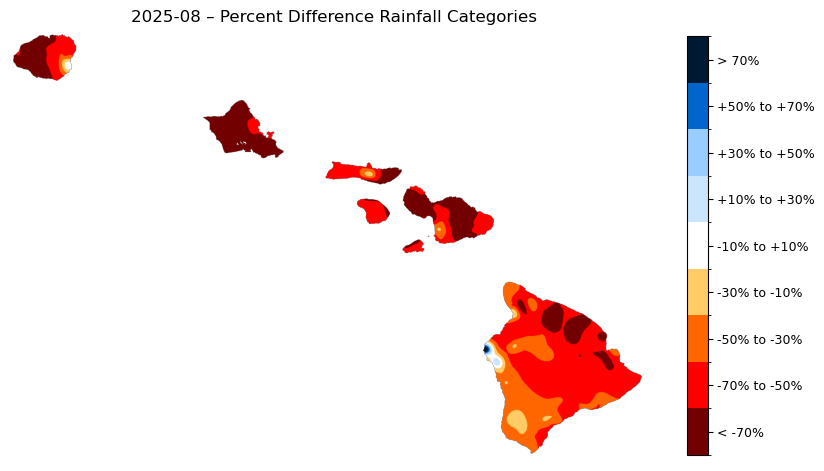

Dataset leans dry. Legend ordered Dry to Wet.
Month 9: Standard rainfall variation. Using default static scale.


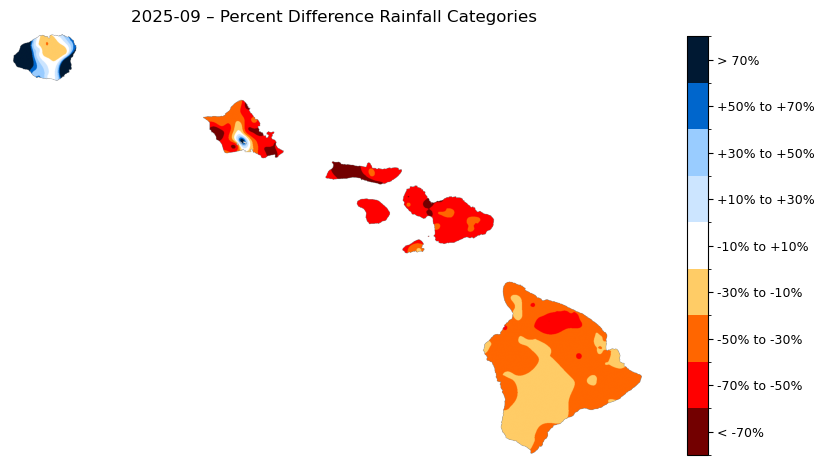

Dataset leans dry. Legend ordered Dry to Wet.
Month 10: Standard rainfall variation. Using default static scale.


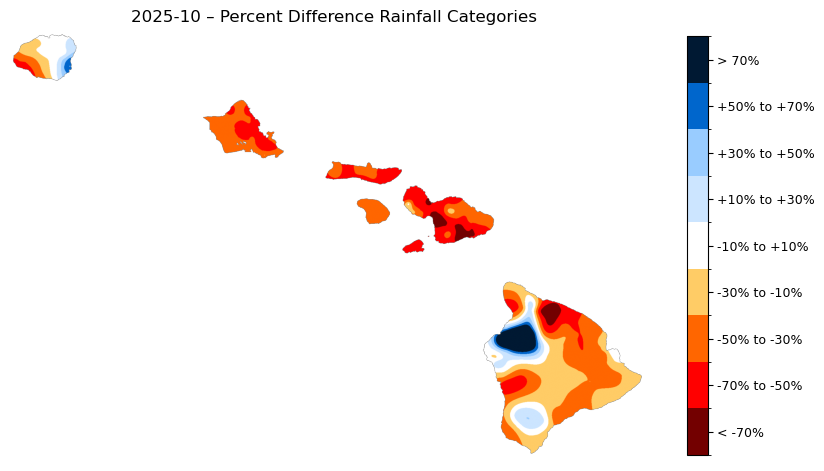

Dataset leans dry. Legend ordered Dry to Wet.
Month 11: Standard rainfall variation. Using default static scale.


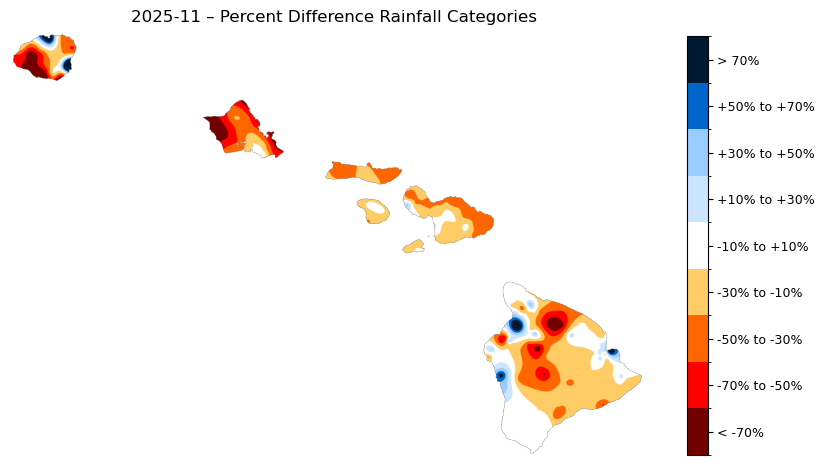

Dataset leans dry. Legend ordered Dry to Wet.
Month 12: Standard rainfall variation. Using default static scale.


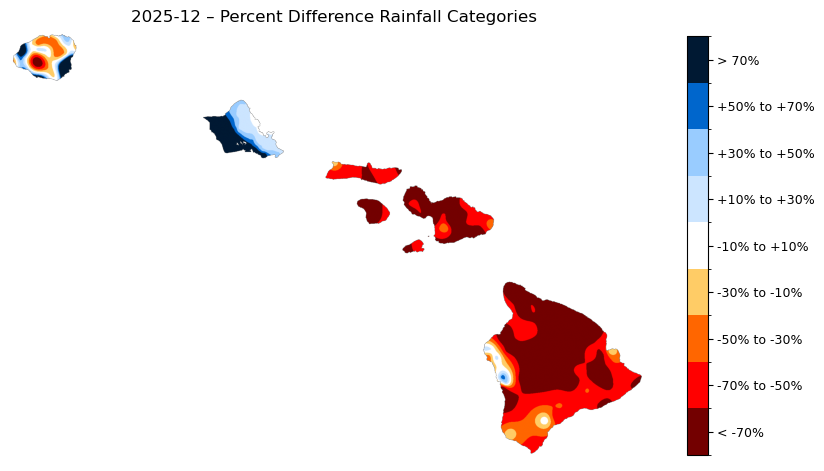

Dataset leans dry. Legend ordered Dry to Wet.


In [50]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

year = '2025'
dataset = 'rainfall'
local_dep_dir = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/scripts/data/dependencies"

for month in range(1, 12+1):
  dataset = 'rainfall'
  local_dep_dir = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/scripts/data/dependencies"

    # 1. Load the Climatology Raster
  climo_file = os.path.join(local_dep_dir, f"climo/{dataset}/{dataset}_1991-2020_{month:02d}.tif")
  with rasterio.open(climo_file) as src:
      rf_climo = src.read(1)
      nodata_climo = src.nodata

  masked_climo = np.ma.masked_equal(rf_climo, nodata_climo)

  # 2. Load the Current Rainfall Raster
  raster_dir = os.path.join(local_dep_dir, dataset, f"{dataset}_{year}_{month:02d}.tif")
  with rasterio.open(raster_dir) as src:
      rf = src.read(1)
      nodata_rf = src.nodata

  masked_rf = np.ma.masked_equal(rf, nodata_rf)

  # 3. Calculate Percent Difference (In Memory)
  pdiff = (masked_rf - masked_climo) / masked_climo * 100
  combined_mask = np.ma.getmask(masked_rf) | np.ma.getmask(masked_climo)
  pdiff_masked = np.ma.array(pdiff, mask=combined_mask)

  data = pdiff_masked.data
  is_data_mask = ~pdiff_masked.mask

  valid_data = data[is_data_mask]
  if len(valid_data) == 0:
      raise ValueError("No valid data found in the raster!")

  # Define our anchor for "Normal" rainfall
  neutral_low = -10.0
  neutral_high = 10.0

  # Isolate the strictly positive pixels for dynamic calculation
  pos_data = valid_data[valid_data > neutral_high]

  # --- DEFAULT VS DYNAMIC SCALE LOGIC ---

  # Negative values are capped at -100%, so we can confidently use static breaks
  n_breaks = [-70, -50, -30]

  # Sensible default breaks for normal positive anomalies
  default_p_breaks = [30, 50, 70]

  # Define what constitutes a "crazy" high rainfall event (e.g., 98th percentile > +150%)
  extreme_high_threshold = 150
  is_crazy_high = np.percentile(valid_data, 98) > extreme_high_threshold

  if is_crazy_high:
      print(f"Month {month}: Extreme high rainfall detected. Using dynamic positive scale.")
      if len(pos_data) > 0:
          p_breaks = np.percentile(pos_data, [25, 50, 75])
      else:
          p_breaks = default_p_breaks
  else:
      print(f"Month {month}: Standard rainfall variation. Using default static scale.")
      p_breaks = default_p_breaks

  # --------------------------------------

  base_colors = [
      "#730000", "#FF0000", "#FF6600", "#FFCC66", # Negatives (0-3)
      "#FFFFFF",                                 # Neutral (4)
      "#CCE5FF", "#99CCFF", "#0066CC", "#001933" # Positives (5-8)
  ]

  # Construct the mathematical bounds using the breaks
  bounds = [
      (-np.inf, n_breaks[0]),       # 0: < Dark Red
      (n_breaks[0], n_breaks[1]),   # 1: Red
      (n_breaks[1], n_breaks[2]),   # 2: Orange
      (n_breaks[2], neutral_low),   # 3: Light Orange
      (neutral_low, neutral_high),  # 4: White
      (neutral_high, p_breaks[0]),  # 5: Very Light Blue
      (p_breaks[0], p_breaks[1]),   # 6: Light Blue
      (p_breaks[1], p_breaks[2]),   # 7: Blue
      (p_breaks[2], np.inf)         # 8: > Dark Blue
  ]

  sync_config = []
  for i, (low, high) in enumerate(bounds):
      color = base_colors[i]
      
      if i == 0:
          label = f"< {high:.0f}%"
      elif i == 8:
          label = f"> {low:.0f}%"
      else:
          low_str = f"+{low:.0f}" if low > 0 else f"{low:.0f}"
          high_str = f"+{high:.0f}" if high > 0 else f"{high:.0f}"
          label = f"{low_str}% to {high_str}%"
          
      sync_config.append((low, high, color, label))

  colors = [c for _, _, c, _ in sync_config]
  labels = [l for _, _, _, l in sync_config]

  categorical = np.full(data.shape, 255, dtype=np.uint8)

  for i, (low, high) in enumerate(bounds):
      if i == 8:
          mask = is_data_mask & (data >= low)
      else:
          mask = is_data_mask & (data >= low) & (data < high)
          
      categorical[mask] = i

  cmap = ListedColormap(colors)
  cmap.set_bad(color='#00000000') 

  norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

  plt.figure(figsize=(9, 6))

  categorical_masked = np.ma.masked_where(categorical == 255, categorical)

  im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
  plt.axis("off")

  cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
  cbar.set_ticks(range(len(colors)))
  cbar.set_ticklabels(labels)
  cbar.ax.tick_params(labelsize=9)
  plt.title(f"{year}-{month:02d} – Percent Difference Rainfall Categories")

  plt.show()

  profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)


  is_wet_heavy = np.median(valid_data) > 0

  legend_items = []
  for i, (low, high, color, label) in enumerate(sync_config):
      # JSON doesn't handle np.inf well, so we convert infinities to None (null in JSON)
      # and standard numpy floats to standard Python floats.
      safe_low = None if np.isinf(low) else float(low)
      safe_high = None if np.isinf(high) else float(high)
      
      legend_items.append({
          "category_value": i, # Matches the pixel value in your TIF
          "color": color,
          "label": label,
          "min": safe_low,
          "max": safe_high
      })

  if is_wet_heavy:
      legend_items.reverse()
      print("Dataset leans wet. Legend ordered Wet to Dry.")
  else:
      print("Dataset leans dry. Legend ordered Dry to Wet.")
